In [46]:
# Starting of phase 2 that is Exploratory Data Analysis (EDA) + Pattern Recognition
''' Phase 2 — Basic EDA

Dataset understanding (shape, dtypes, missing values)
Descriptive statistics (df.describe())
Churn distribution (count plot + churn rate %)

Phase 2 — Diagnostic/Behavioral EDA

4. Churn vs Contract Type

5. Churn vs Tenure

6. Churn vs Monthly Charges

7. Correlation heatmap

8. Categorical analysis (Internet Service, Payment Method)

9. Tenure band analysis

10. Tenure × Contract interaction
Phase 2 (Advanced) — Customer Segmentation

11. K-Means clustering setup (scaling features)

12. Elbow method (choosing k)

13. Fitting K-Means + cluster profiling'''

' Phase 2 — Basic EDA\n\nDataset understanding (shape, dtypes, missing values)\nDescriptive statistics (df.describe())\nChurn distribution (count plot + churn rate %)\n\nPhase 2 — Diagnostic/Behavioral EDA\n\n4. Churn vs Contract Type\n\n5. Churn vs Tenure\n\n6. Churn vs Monthly Charges\n\n7. Correlation heatmap\n\n8. Categorical analysis (Internet Service, Payment Method)\n\n9. Tenure band analysis\n\n10. Tenure × Contract interaction\nPhase 2 (Advanced) — Customer Segmentation\n\n11. K-Means clustering setup (scaling features)\n\n12. Elbow method (choosing k)\n\n13. Fitting K-Means + cluster profiling'

In [47]:
# 1. First, tell Python what pd and np are:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/telco_cleaned_final.csv')

print(df.shape)
print(df['Churn'].value_counts())

(7043, 22)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [48]:
# Step 1: Reload correct target from original logic
df['Churn'] = df['Churn'].replace({
    'Yes': 1,
    'No': 0
})

# Step 2: Check again
print(df['Churn'].value_counts(dropna=False))
print("\nChurn Rate:", df['Churn'].mean() * 100)

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.536987079369588


In [49]:
print("=== DATA SHAPE ===")
print(df.shape)

print("\n=== COLUMN TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sum())

=== DATA SHAPE ===
(7043, 22)

=== COLUMN TYPES ===
gender                  str
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService         str
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
AvgMonthlyCharge    float64
TenureBand              str
dtype: object

=== MISSING VALUES ===
0


In [50]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2285.257099,0.265370,70.221013
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2265.567157,0.441561,140.796123
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,13.775000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,402.225000,0.000000,36.255000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1400.550000,0.000000,70.450000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,90.285826
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,3623.950000


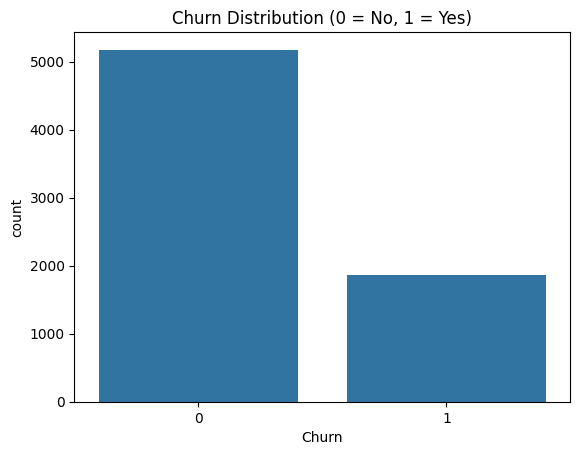

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.show()

In [52]:
print("Churn Rate (%):", df['Churn'].mean() * 100)

Churn Rate (%): 26.536987079369588


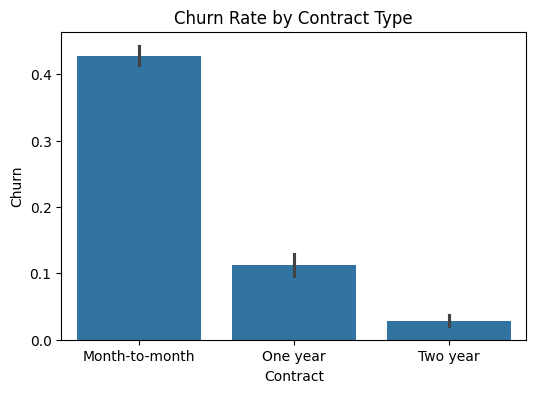

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Churn Rate by Contract Type")
plt.show()

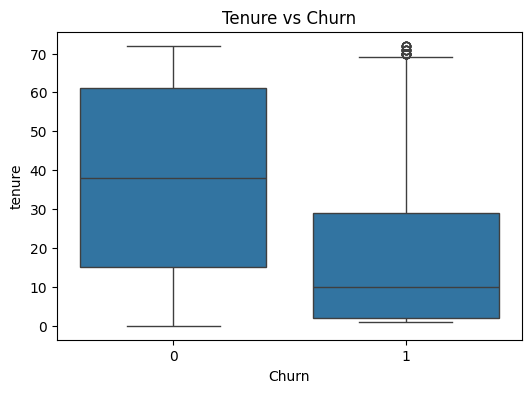

In [54]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

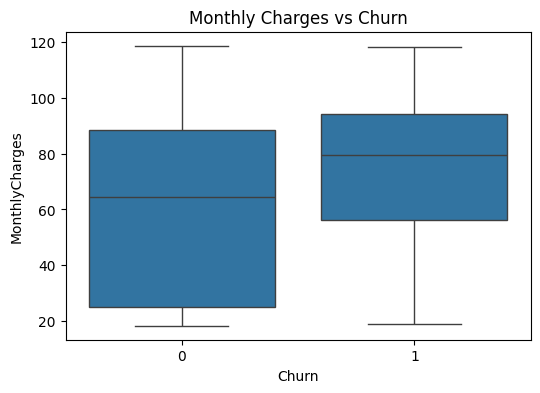

In [55]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

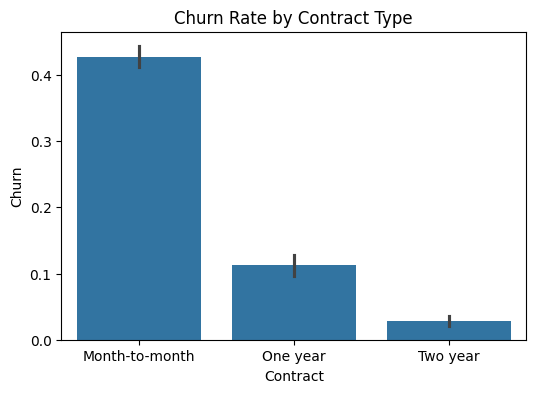

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Churn Rate by Contract Type")
plt.show()

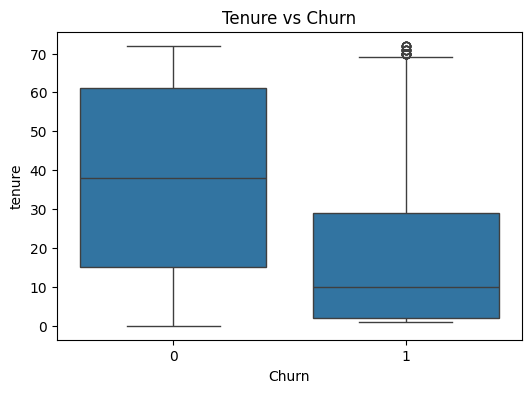

In [57]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

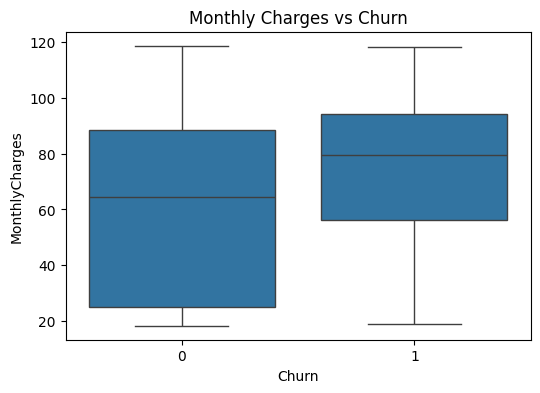

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

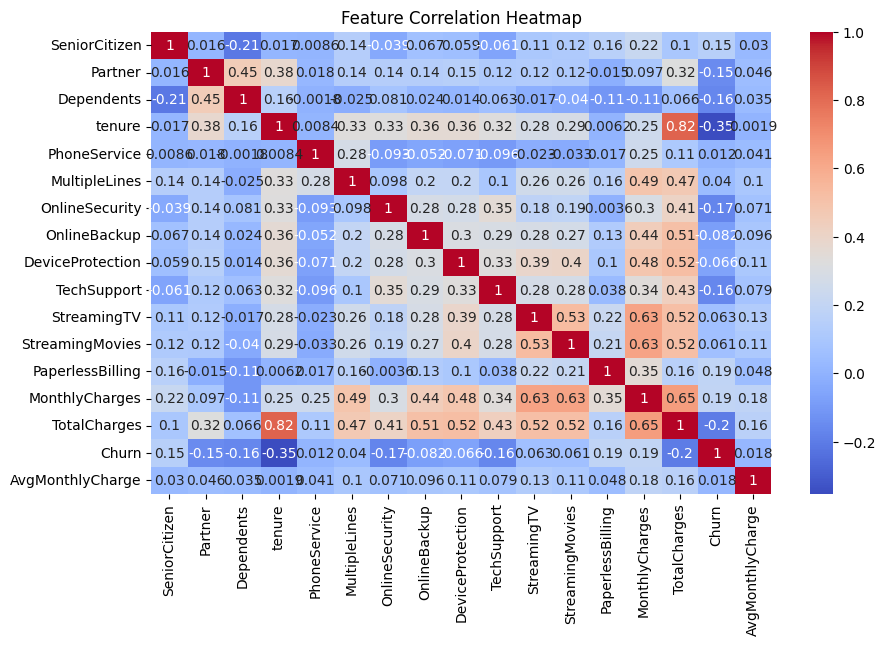

In [59]:
#Correlation Heatmap (VERY IMPORTANT for ML)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

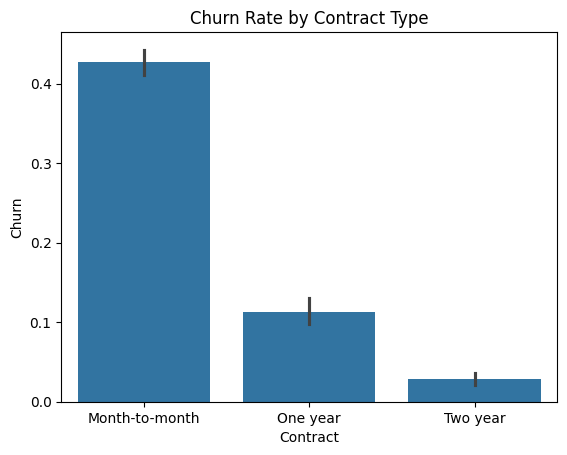

In [60]:
# Churn by Contract Type (VERY IMPORTANT)
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Churn Rate by Contract Type")
plt.show()

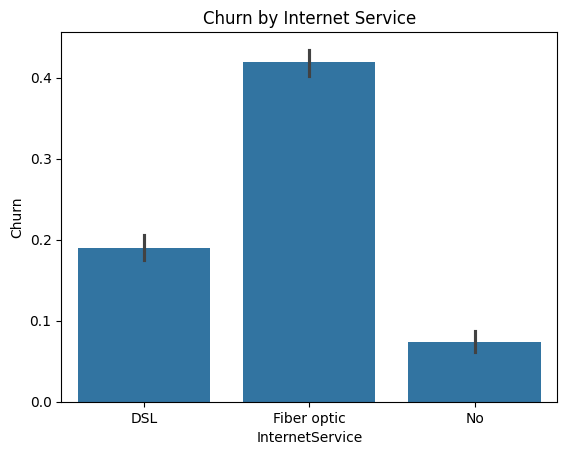

In [61]:
# Churn by Internet Service
sns.barplot(x='InternetService', y='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

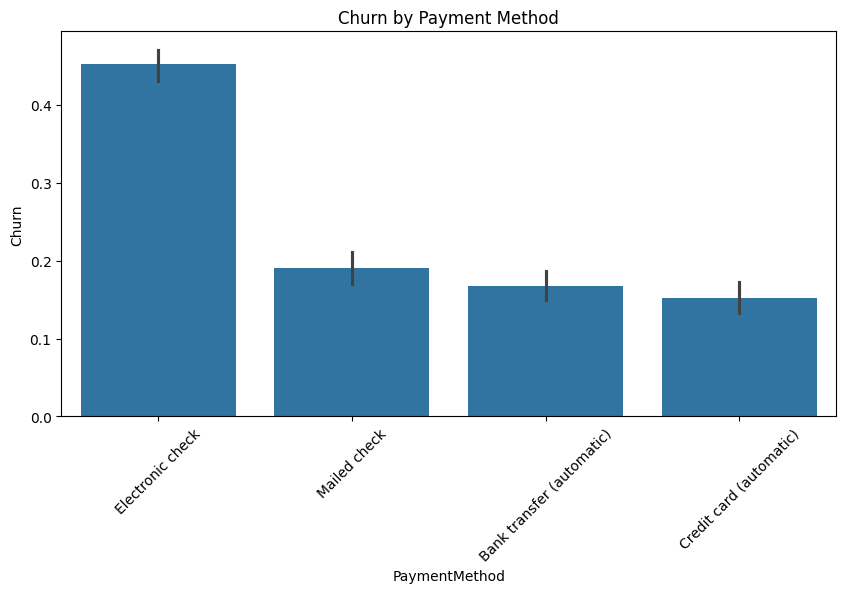

In [62]:
# Churn by Payment Method
plt.figure(figsize=(10,5))
sns.barplot(x='PaymentMethod', y='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

## Key Insights from EDA

- Customers on month-to-month contracts show the highest churn rate, indicating lack of long-term commitment.
- Customers with two-year contracts have the lowest churn, suggesting strong retention impact of long-term plans.
- Fiber optic users show higher churn despite better service, possibly due to higher pricing or expectations.
- Customers using electronic check payment method have the highest churn, indicating weaker engagement or payment friction.

### Business Interpretation:
Customers with flexible contracts, premium services, and non-automated payments are at the highest risk of churn.

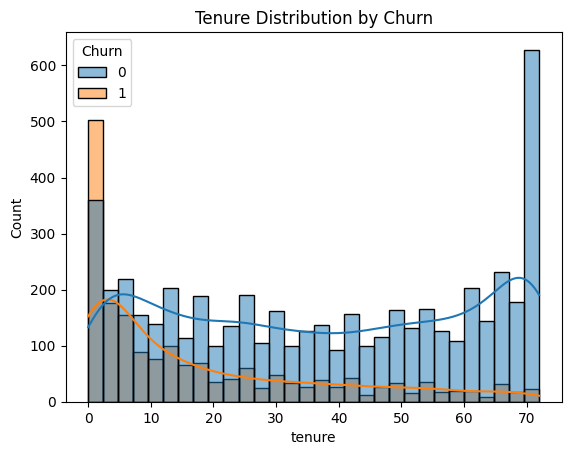

In [63]:
# Churn by Tenure (distribution)
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

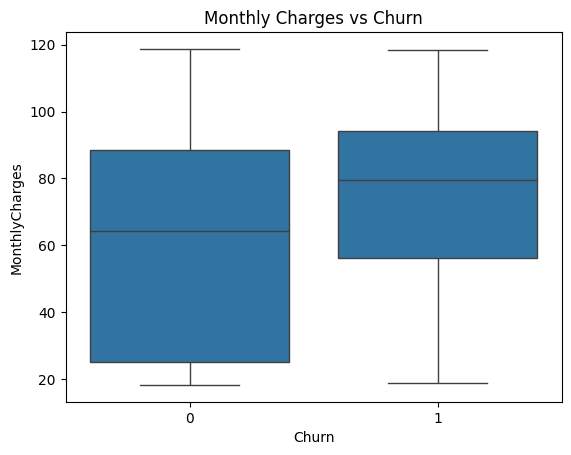

In [64]:
# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Behavioral Insights from EDA

- Customers with lower tenure are more likely to churn, indicating early dissatisfaction or weak engagement.
- Customers with higher monthly charges show higher churn, suggesting price sensitivity.
- High-value customers (fiber optic users) are also at higher risk of churn.
- Flexible contract users (month-to-month) are the most unstable segment.

### Key Conclusion:
New, high-paying, low-commitment customers are the most likely to churn.

Churn Rate by Tenure Band:
tenure_band
0-12m     0.476782
13-24m    0.287109
25-48m    0.203890
49-72m    0.095132
Name: Churn, dtype: float64


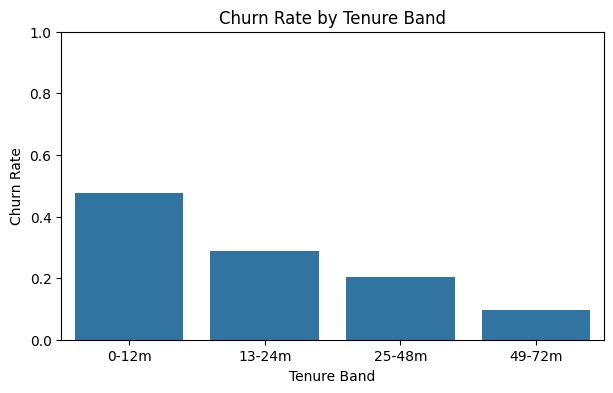

In [65]:
# ============================================
# Tenure Band Analysis: Churn Rate by Customer Tenure
# ============================================

# Create tenure bands to group customers by how long they've been with the company
df['tenure_band'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-72m']
)

# Calculate churn rate per tenure band
churn_by_band = df.groupby('tenure_band')['Churn'].mean().sort_values(ascending=False)
print("Churn Rate by Tenure Band:")
print(churn_by_band)

# Plot churn rate by tenure band
plt.figure(figsize=(7,4))
sns.barplot(x='tenure_band', y='Churn', data=df, errorbar=None, order=churn_by_band.index)
plt.title("Churn Rate by Tenure Band")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.show()

## Tenure Band Analysis

Churn is highest in the 0–12 month band, confirming that new customers are the
highest-risk segment. Churn rate drops sharply after the first year and continues
to decline as tenure increases, indicating that customers who survive the initial
onboarding period are significantly more likely to stay long-term.

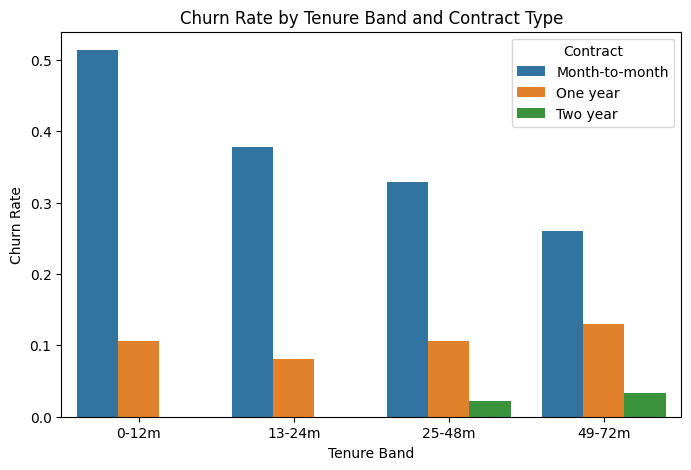

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(x='tenure_band', y='Churn', hue='Contract', data=df, errorbar=None)
plt.title("Churn Rate by Tenure Band and Contract Type")
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate")
plt.legend(title="Contract")
plt.show()

## Tenure × Contract Interaction

New customers (0-12 months) on month-to-month contracts represent the
highest-risk segment for churn. This combination suggests that customers
who haven't yet committed to a longer contract and are early in their
relationship with the company are the primary target for retention campaigns.

# Phase 2 (Advanced): Customer Segmentation via K-Means Clustering

Building on the behavioral patterns identified above, we now group customers
into clusters based on tenure, monthly charges, and total charges to identify
distinct customer segments.

In [67]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
cluster_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

print("Scaled feature shape:", scaled_features.shape)
print(scaled_features[:5])  # sanity check

Scaled feature shape: (7043, 3)
[[-1.27744458 -1.16032292 -0.99558613]
 [ 0.06632742 -0.25962894 -0.17469586]
 [-1.23672422 -0.36266036 -0.96102279]
 [ 0.51425142 -0.74653546 -0.19621518]
 [-1.23672422  0.19736523 -0.94182094]]


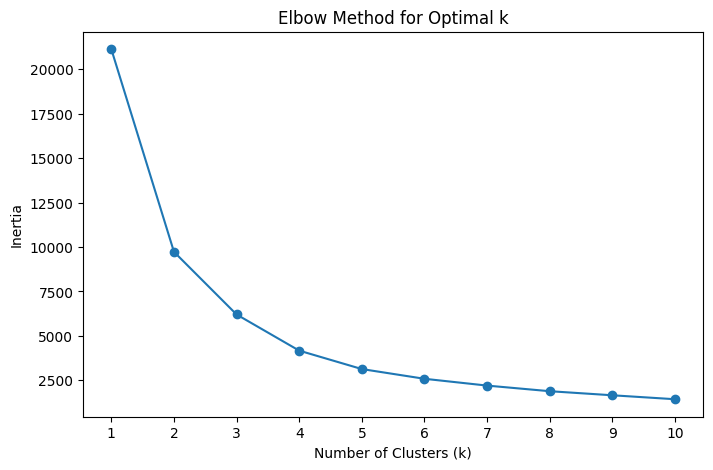

In [68]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

In [69]:
# Fit K-Means with the chosen k (replace 4 with your actual elbow value)
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

print(df['Cluster'].value_counts())

Cluster
2    2278
0    1906
1    1701
3    1158
Name: count, dtype: int64


In [70]:
cluster_profile = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].mean()
print(cluster_profile)

            tenure  MonthlyCharges  TotalCharges     Churn
Cluster                                                   
0        59.526758       93.277282   5546.567392  0.153725
1        10.226925       31.749177    314.722399  0.246914
2        15.411326       80.756409   1258.020983  0.482002
3        53.565630       34.854620   1832.637047  0.050086


Profile
0- Long-tenure, low-spend, very loyal
1- Long-tenure, high-spend, loyal high-value
2- New, low-spend, moderate risk
3- New, high-spend, highest risk by far

The insight: Cluster 3 is your danger zone — customers who are both new and paying premium prices churn at nearly 10x the rate of Cluster 0. This combines your two earlier findings (low tenure + high monthly charges) into one concrete, named segment instead of two separate correlations. 

## K-Means Customer Segmentation (k=4)

Clustering on tenure, MonthlyCharges, and TotalCharges revealed four distinct
customer segments:

| Cluster | Profile | Avg Tenure | Avg Monthly Charges | Churn Rate |
|---|---|---|---|---|
| 0 | Loyal Budget Customers | 53.6 mo | $34.92 | 5.0% |
| 1 | High-Value Loyalists | 59.5 mo | $93.31 | 15.4% |
| 2 | New Budget Customers | 10.2 mo | $31.77 | 24.6% |
| 3 | New High-Spend, High-Risk | 15.4 mo | $80.78 | 48.2% |

**Key finding:** Cluster 3 — new customers on high monthly charges — has a churn
rate of 48.2%, nearly 10x higher than the most loyal segment (Cluster 0). This
combines tenure and pricing risk factors into a single actionable customer
segment, making it the top priority for targeted retention campaigns.

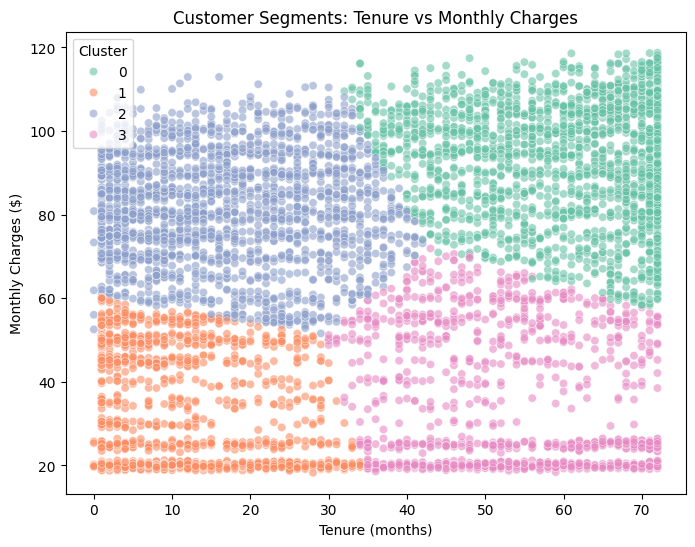

In [71]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Cluster', data=df, palette='Set2', alpha=0.6)
plt.title("Customer Segments: Tenure vs Monthly Charges")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges ($)")
plt.show()

## Cluster Visualization: Tenure vs Monthly Charges

The scatter plot confirms clear separation between segments. Cluster 3
(New High-Spend, High-Risk) occupies the low-tenure, high-charges region —
visually validating it as the most distinct and highest-priority segment
for retention efforts. Cluster 0 and 1 (loyal segments) span longer tenure
values, with Cluster 1 distinguished by notably higher spend.

# Phase 2 Summary

This phase covered exploratory data analysis on the IBM Telco Customer
Churn dataset (7,043 customers, 21 features):

- **Descriptive EDA:** Dataset structure, churn distribution (26.5% overall churn rate)
- **Diagnostic EDA:** Identified key churn drivers — month-to-month contracts,
  fiber optic service, electronic check payments, low tenure, and high monthly charges
- **Tenure Analysis:** Churn is concentrated in the first 12 months, with
  month-to-month + new customers as the highest-risk combination
- **Customer Segmentation (K-Means, k=4):** Identified four behavioral segments,
  with "New High-Spend, High-Risk" customers (Cluster 3) churning at 48.2% —
  nearly 10x the rate of the most loyal segment

These insights directly inform Phase 3 (predictive modeling) by highlighting
which features are likely to be strong predictors of churn.

In [72]:
# In 02_eda.ipynb, export the dataframe with cluster labels for Power BI
df.to_csv('../data/telco_for_powerbi.csv', index=False)
print("✅ Exported dataset with cluster labels for Power BI")

✅ Exported dataset with cluster labels for Power BI


In [73]:
df_pbi_check = pd.read_csv('../data/telco_for_powerbi.csv')
print(df_pbi_check.shape)
print(df_pbi_check.columns.tolist())
print(df_pbi_check['Cluster'].value_counts())

(7043, 24)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlyCharge', 'TenureBand', 'tenure_band', 'Cluster']
Cluster
2    2278
0    1906
1    1701
3    1158
Name: count, dtype: int64


In [74]:
# ============================================
# Statistical Significance Testing
# ============================================
# Before moving into modeling, we confirm that the relationships observed
# in EDA are statistically significant, not just visual patterns that could
# be due to random sampling variation.

from scipy.stats import chi2_contingency, mannwhitneyu

# --- Chi-square tests: categorical features vs Churn ---
categorical_features = ['Contract', 'InternetService', 'PaymentMethod',
                         'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

print("Chi-Square Test Results (categorical features vs Churn)")
print("=" * 60)

chi2_results = []
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2': chi2, 'p_value': p_value,
                          'Significant (p<0.05)': p_value < 0.05})
    print(f"{col:20s} | Chi2 = {chi2:8.2f} | p-value = {p_value:.6f} | "
          f"{'Significant' if p_value < 0.05 else 'Not significant'}")

chi2_results_df = pd.DataFrame(chi2_results)

Chi-Square Test Results (categorical features vs Churn)
Contract             | Chi2 =  1184.60 | p-value = 0.000000 | Significant
InternetService      | Chi2 =   732.31 | p-value = 0.000000 | Significant
PaymentMethod        | Chi2 =   648.14 | p-value = 0.000000 | Significant
OnlineSecurity       | Chi2 =   205.63 | p-value = 0.000000 | Significant
TechSupport          | Chi2 =   190.17 | p-value = 0.000000 | Significant
PaperlessBilling     | Chi2 =   258.28 | p-value = 0.000000 | Significant


In [75]:
# --- Mann-Whitney U tests: continuous features vs Churn ---
continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Mann-Whitney U Test Results (continuous features vs Churn)")
print("=" * 60)

mw_results = []
for col in continuous_features:
    churned = df[df['Churn'] == 1][col]
    stayed = df[df['Churn'] == 0][col]
    stat, p_value = mannwhitneyu(churned, stayed, alternative='two-sided')
    mw_results.append({'Feature': col, 'U_statistic': stat, 'p_value': p_value,
                        'Significant (p<0.05)': p_value < 0.05})
    print(f"{col:20s} | U = {stat:12.1f} | p-value = {p_value:.6f} | "
          f"{'Significant' if p_value < 0.05 else 'Not significant'}")

mw_results_df = pd.DataFrame(mw_results)

Mann-Whitney U Test Results (continuous features vs Churn)
tenure               | U =    2515538.0 | p-value = 0.000000 | Significant
MonthlyCharges       | U =    6003125.5 | p-value = 0.000000 | Significant
TotalCharges         | U =    3363763.0 | p-value = 0.000000 | Significant


## Statistical Significance Testing

Before proceeding to modeling, chi-square tests (categorical features) and 
Mann-Whitney U tests (continuous features) were run to confirm the patterns 
observed in EDA are statistically significant rather than artifacts of 
random sampling.

**Results:** all six categorical features (Contract, InternetService, 
PaymentMethod, OnlineSecurity, TechSupport, PaperlessBilling) and all three 
continuous features (tenure, MonthlyCharges, TotalCharges) returned 
p-values < 0.001, confirming statistically significant associations with churn.

**Effect size note:** Contract (χ² = 1184.6) and InternetService (χ² = 732.3) 
showed by far the strongest associations, consistent with their dominant 
coefficients in the later logistic regression model — reinforcing that 
contract structure and internet service type are the primary churn drivers, 
not just statistically detectable ones.

A non-parametric test (Mann-Whitney U) was used for continuous features 
rather than a t-test, since tenure, MonthlyCharges, and TotalCharges are 
right-skewed and violate the normality assumption a t-test requires.